In [6]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from collections import Counter

# 1. Path Setup
PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)
sys.path.append(os.path.join(PROJECT_ROOT, "cs195-ska-projects/shared/ska_agent-1.0.0-8"))

# 2. Imports
from ska_agent.models.embedding import Embedder
from ska_agent.core.pricing import PricingEngine
from shared.constants import LAMBDA_GRID, MODES, MODE_COLORS, LAMBDA_BINS, EPS, TARGET_K_BY_MODE
from shared.corpus import make_officeqa_synthetic_corpus, build_segments_from_texts
from shared.scoring import complexity_aligned_lambda_score, get_selected_indices, ensure_1d
from shared.predictor import LambdaPredictor, train_predictor, stratified_train_val_split
from shared.io_utils import load_records

OUT_W6 = os.path.join(PROJECT_ROOT, "outputs", "week6")
OUT_W8 = os.path.join(PROJECT_ROOT, "outputs", "week8")
os.makedirs(OUT_W8, exist_ok=True)

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif',
    'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.axisbelow': True, 'legend.frameon': False
})

# 3. Load Embedder
print("Loading Embedder...")
embedder = Embedder(model_name="all-MiniLM-L6-v2")

# 4. Rebuild Corpus (CRITICAL: n_per_mode must match what you used in Week 6)
N_PER_MODE = 25 # <-- Change to 25 if you didn't scale up the corpus in Week 6
print(f"Rebuilding Synthetic Corpus (n_per_mode={N_PER_MODE})...")
segment_texts, questions, relevant_by_qid, _ = make_officeqa_synthetic_corpus(n_per_mode=N_PER_MODE)
segments = build_segments_from_texts(segment_texts, embedder)

# 5. Extract the global corpus embeddings matrix once for fast vectorization
corpus_embeddings = np.array([seg.vector for seg in segments], dtype=np.float32)
corpus_norms = np.linalg.norm(corpus_embeddings, axis=1)
corpus_norms[corpus_norms == 0] = 1e-10  # Prevent division by zero

# 6. Load Week 6 Sweep Records
train_records = load_records(os.path.join(OUT_W6, "train_sweep_records.json"))
test_records = load_records(os.path.join(OUT_W6, "test_sweep_records.json"))

print(f"Loaded {len(segments)} segments successfully.")
print(f"Loaded {len(train_records)} train records and {len(test_records)} test records.")

Loading Embedder...
No GPU found. Using lightweight CPU embedder: Alibaba-NLP/gte-Qwen2-1.5B-instruct
Loading embedding model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/Users/kevincapcha/PycharmProjects/CS195S2026/outputs/cs195-ska-projects/shared/ska_agent-1.0.0-8/ska_agent/models/embedding.py:51: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.embedding_dim = self.model.get_sentence_embedding_dimension()


Embedder ready (dim=384)
Rebuilding Synthetic Corpus (n_per_mode=25)...
Loaded 275 segments successfully.
Loaded 4480 train records and 1120 test records.


In [7]:
def extract_density_features(query_emb: np.ndarray, corpus_embs: np.ndarray, c_norms: np.ndarray) -> np.ndarray:
    """Computes local corpus density statistics for a given query."""
    q_norm = np.linalg.norm(query_emb)
    if q_norm == 0: q_norm = 1e-10

    sims = np.dot(corpus_embs, query_emb) / (c_norms * q_norm)
    sims_sorted = np.sort(sims)[::-1]

    top_20 = sims_sorted[:20]
    mean_top20 = np.mean(top_20) if len(top_20) > 0 else 0.0
    var_top20 = np.var(top_20) if len(top_20) > 0 else 0.0

    gap_1_5 = top_20[0] - top_20[4] if len(top_20) > 4 else 0.0
    gap_1_20 = top_20[0] - top_20[-1] if len(top_20) > 19 else 0.0

    hist_counts, _ = np.histogram(sims, bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

    return np.array([mean_top20, var_top20, gap_1_5, gap_1_20, *hist_counts], dtype=np.float32)

def build_hybrid_dataset(records, embed_fn, corpus_embs, c_norms):
    """Augments standard query embeddings with corpus density features."""
    optimal = [r for r in records if r["is_optimal"]]
    queries = [r["query"] for r in optimal]
    modes = [r["mode"] for r in optimal]
    y = np.asarray([r["lambda"] for r in optimal], dtype=np.float32)

    X_hybrid = []
    for query in queries:
        q_emb = ensure_1d(embed_fn(query)).astype(np.float32)
        density_feats = extract_density_features(q_emb, corpus_embs, c_norms)
        fused_vector = np.concatenate([q_emb, density_feats])
        X_hybrid.append(fused_vector)

    return np.asarray(X_hybrid, dtype=np.float32), y, queries, modes

print("Building Hybrid Train Dataset...")
X_tr_hybrid, y_tr_hybrid, tr_queries, tr_modes = build_hybrid_dataset(
    train_records, embedder.embed_single, corpus_embeddings, corpus_norms
)
print(f"Hybrid Input Dimension: {X_tr_hybrid.shape[1]}")

Building Hybrid Train Dataset...
Hybrid Input Dimension: 393



Training Hybrid MLP Regressor...
Epoch 000 | train log-MSE=14.9160 | val log-MSE=15.5374
Epoch 050 | train log-MSE=2.5051 | val log-MSE=3.2996
Epoch 100 | train log-MSE=1.5694 | val log-MSE=2.4388
Epoch 150 | train log-MSE=1.4376 | val log-MSE=2.3714
Epoch 200 | train log-MSE=1.3421 | val log-MSE=2.3142
Epoch 249 | train log-MSE=1.2442 | val log-MSE=2.2576


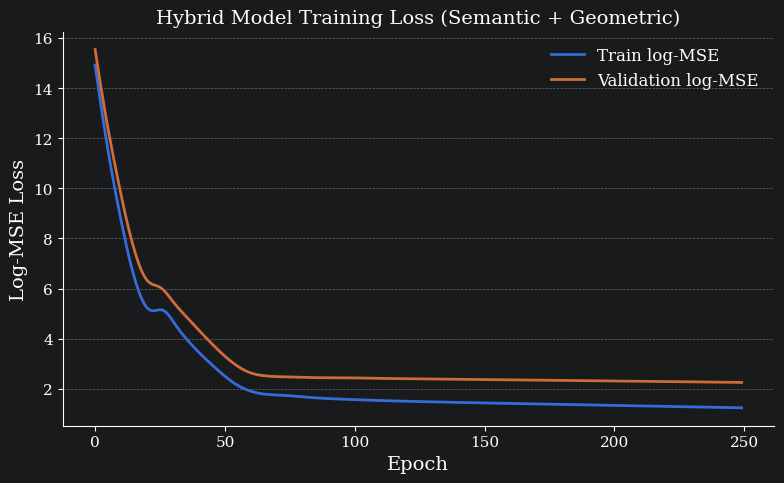

In [8]:
# Internal Validation Split for training stability
X_tr, X_va, y_tr, y_va, _, _ = stratified_train_val_split(
    X=X_tr_hybrid, y=y_tr_hybrid, modes=tr_modes, val_frac=0.2, seed=SEED
)

print("\nTraining Hybrid MLP Regressor...")
hybrid_model, train_losses, val_losses = train_predictor(
    X_tr, y_tr, X_va, y_va, hidden_dim=64, num_epochs=250, lr=1e-3, seed=SEED
)

# Plot Loss
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label="Train log-MSE", linewidth=2)
ax.plot(val_losses, label="Validation log-MSE", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Log-MSE Loss")
ax.set_title("Hybrid Model Training Loss (Semantic + Geometric)")
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
def predict_hybrid_lambda(model: LambdaPredictor, query_text: str) -> float:
    """Inference wrapper: Embeds query, extracts density, predicts lambda."""
    q_emb = ensure_1d(embedder.embed_single(query_text)).astype(np.float32)
    density_feats = extract_density_features(q_emb, corpus_embeddings, corpus_norms)
    hybrid_vec = np.concatenate([q_emb, density_feats])
    tensor_in = torch.tensor(hybrid_vec, dtype=torch.float32).unsqueeze(0)

    return float(model.predict_lambda(tensor_in)[0])

def evaluate_retrieval(query_text, q_id, q_mode, lam_val, engine):
    """Runs the pricing engine and returns metrics."""
    engine.lambda_sparsity = lam_val
    result = engine.retrieve(query_text, verbose=False)

    selected_indices = get_selected_indices(result)
    relevant_indices = relevant_by_qid[q_id]

    _, metrics = complexity_aligned_lambda_score(selected_indices, relevant_indices, q_mode)
    metrics["total_reduced_cost"] = float(np.sum(result.reduced_costs)) if result.reduced_costs is not None else 0.0
    return metrics

print("Running End-to-End Evaluation on TEST SET...")

# Shared engine (hot-swapping lambda)
eval_engine = PricingEngine(
    segments=segments, embed_fn=embedder.embed_single,
    lambda_sparsity=0.05, eta_redundancy=0.0, max_segments=5
)

results = {"fixed_default": [], "fixed_best": [], "learned_hybrid": [], "oracle": []}

# Process only the questions in the test set
test_qids = set(r["question_id"] for r in test_records)
eval_questions = [q for q in questions if q.question_id in test_qids]

for q in eval_questions:
    results["fixed_default"].append(evaluate_retrieval(q.question, q.question_id, q.question_type, 0.05, eval_engine))
    results["fixed_best"].append(evaluate_retrieval(q.question, q.question_id, q.question_type, 0.10, eval_engine))

    dyn_lambda = predict_hybrid_lambda(hybrid_model, q.question)
    results["learned_hybrid"].append(evaluate_retrieval(q.question, q.question_id, q.question_type, dyn_lambda, eval_engine))

    oracle_lam = next((r["lambda"] for r in test_records if r["question_id"] == q.question_id and r["is_optimal"]), 0.05)
    results["oracle"].append(evaluate_retrieval(q.question, q.question_id, q.question_type, oracle_lam, eval_engine))

print("\n\nHybrid Model Comparison vs Baselines (Unseen Test Set):")
print(f"{'Config':<18} {'AvgCov':>10} {'AvgSegs':>10} {'AvgPrec':>10} {'AvgRC':>10}")
print("-" * 62)

display_names = {
    "fixed_default": "Fixed (0.05)", "fixed_best": "Fixed (0.10)",
    "learned_hybrid": "Hybrid MLP", "oracle": "Oracle"
}

for cfg in ["fixed_default", "fixed_best", "learned_hybrid", "oracle"]:
    covs = np.mean([r["evidence_coverage"] for r in results[cfg]])
    segs = np.mean([r["num_selected"] for r in results[cfg]])
    precs = np.mean([r["precision"] for r in results[cfg]])
    rcs = np.mean([r["total_reduced_cost"] for r in results[cfg]])

    print(f"{display_names[cfg]:<18} {covs:>10.3f} {segs:>10.2f} {precs:>10.3f} {rcs:>10.3f}")

Running End-to-End Evaluation on TEST SET...


Hybrid Model Comparison vs Baselines (Unseen Test Set):
Config                 AvgCov    AvgSegs    AvgPrec      AvgRC
--------------------------------------------------------------
Fixed (0.05)            0.483       1.20      0.767     -0.519
Fixed (0.10)            0.483       1.00      0.800     -0.467
Hybrid MLP              0.483       1.70      0.613     -0.536
Oracle                  0.567       1.70      0.762     -0.529
